## 0. 배경 · 문제의식 · 목적

Part 1에서 "첫 구매 후 장바구니 재추가 여부"는 재구매와 가장 강한 연관성
(Cramér's V = 0.505)을 보인 요인이었다. Part 2 모델에서도 이 변수
(`post_cart_yn`)가 가장 큰 예측력(LR 계수 0.641, 1위)을 가졌다.

문제는 이게 상관관계라는 것. "장바구니 재추가한 사람이 재구매를 잘 한다"와
"장바구니 재추가가 재구매를 만든다"는 다른 얘기다. 둘 다 "원래 구매 의향이
높은 사람"이라는 공통 원인 때문에 같이 나타나는 것일 수도 있다.

| 질문 | 답변 여부 |
|---|---|
| 장바구니 재추가한 사람이 재구매할까? (예측) | Part 2 |
| CRM으로 장바구니 재추가를 유도하면 재구매가 늘어날까? (개입) | 아직 없음 |

관측된 구매 전 특성을 보정한 뒤에도 재구매율 차이가 남는지 살펴보고, CRM 실험 후보를 제안한다.

### 분석과정

1. T-Y-W 구조를 DAG로 명시 (Model)
2. Backdoor Criterion으로 식별 가능성 확인 (Identify)
3. PSM/IPW로 설정한 인과 가정 아래 ATE 추정 (Estimate)
4. Refutation Test로 강건성 검증 (Refute)

### 분석 대상

| 구분 | 내용 |
|---|---|
| 처치(T) | `post_cart_yn` — 첫 구매 후 24시간 이상~8일 미만, 재구매 이전의 장바구니 재추가 여부 |
| 결과(Y) | `repurchase` — 경과 일수 버림값 18 이하(19일 미만)의 두 번째 purchase 이벤트 여부 |
| 교란요인(W) | 구매 전 조회수/장바구니 횟수, 첫 구매 가격·카테고리, 데이터에서 첫 관측~첫 구매 기간 |
| 방법론 | DoWhy (Model → Identify → Estimate → Refute), PSM/IPW |
| 표본 | 첫 구매 유저 332,125명 (T=1: 31,859 / T=0: 300,266) |

> 실행 기록: 원본 시간 조건의 저장 데이터 `feature_df_fixed.pkl`(332,125명)로 추정·균형·추가 검증 셀을 재실행했다. 원시 이벤트 전처리와 그래프, 신뢰구간 셀은 이번에 재실행하지 않았다. 추가 검증은 저장 성향점수를 제거해 재적합하며 각 검증 seed=42, Placebo/부분 표본은 각각 100회다.


## 1. 데이터 준비 — T/Y/W 정의

Part 2에서 만든 `feature_df`를 그대로 쓰되, 역할을 T/Y/W로 재정의한다.

Part 2 피처 중 `post_cart_yn` 하나만 처치로 골랐다. 이유는 세 가지.

| 기준 | post_cart_yn | 다른 post-purchase 피처 |
|---|---|---|
| 개입 가능 | CRM(재입고 알림 등)으로 유도 가능 | `first_purchase_price` 등은 이미 확정된 과거 값 |
| 시간 순서 | 첫 구매 후, 재구매 이전으로 명확 | `pre_view_count` 등은 T보다 먼저 일어나 W에 더 가까움 |
| 신호 강도 | V=0.505, LR 계수 1위 | 상대적으로 약함 |

- **T**: `post_cart_yn` — 첫 구매 후 24시간 이상~8일 미만, 두 번째 구매보다 반드시
  이전인 장바구니 이벤트 여부
- **Y**: `repurchase` — 경과 일수 버림값 18 이하(19일 미만)의 두 번째 purchase 이벤트 여부
- **W**: `pre_view_count`, `pre_cart_count`, `first_purchase_price`,
  `days_to_first_purchase`, 카테고리 더미(`cat_apparel`, `cat_appliances`,
  `cat_computers`, 기준=electronics)

`post_view_yn`, `repeat_view_yn`은 T와 같은 7일 창 안에서 일어나 시간
순서가 애매해서 W에서 뺐다.

*`post_cart_yn`은 재구매가 이미 일어난 뒤의 장바구니 이벤트까지 처치로
잡는 문제가 있어서, second_purchase_time 이전으로 관측창을 제약해 다시
계산한 값을 쓴다.*

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# ── 0. 원본 데이터 로드 ──────────────────────────────────────
df1 = pd.read_pickle("clean_events.pkl")
df1['event_time'] = pd.to_datetime(df1['event_time'])
last_date = df1['event_time'].max()

# ── 1. 분석 대상 확정 (Part 2, N=18일 이상 관측 가능 유저) ──
purchases = df1[df1['event_type'] == 'purchase'].copy()

first_purchase = (
    purchases.groupby('user_id')['event_time']
    .min().reset_index()
    .rename(columns={'event_time': 'first_purchase_time'})
)
first_purchase['days_remaining'] = (last_date - first_purchase['first_purchase_time']).dt.days
analysis_users = first_purchase[first_purchase['days_remaining'] >= 18].copy()

purchase_counts = (
    purchases.groupby('user_id')
    .apply(lambda x: x.sort_values('event_time')['event_time'].iloc[1]
           if len(x) >= 2 else pd.NaT)
    .reset_index()
    .rename(columns={0: 'second_purchase_time'})
)
analysis_users = analysis_users.merge(purchase_counts, on='user_id', how='left')

# .dt.days <= 18은 19일 미만이다. 최소 18일 관측 조건과 완전히 일치하지 않는다.
analysis_users['days_to_repurchase'] = (
    analysis_users['second_purchase_time'] - analysis_users['first_purchase_time']
).dt.days
analysis_users['repurchase'] = (analysis_users['days_to_repurchase'] <= 18).astype(int)

first_event_time = (
    df1.groupby('user_id')['event_time'].min()
    .reset_index().rename(columns={'event_time': 'first_event_time'})
)
analysis_users = analysis_users.merge(first_event_time, on='user_id', how='left')
analysis_users['days_to_first_purchase'] = (
    analysis_users['first_purchase_time'] - analysis_users['first_event_time']
).dt.days

print(f'분석 대상 유저 수: {len(analysis_users):,}명')  # 332,125명 나와야 정상

# ── 2. Pre-purchase 피처 ─────────────────────────────────────
pre_events = df1.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
pre_events = pre_events[pre_events['event_time'] < pre_events['first_purchase_time']]

pre_views = (pre_events[pre_events['event_type']=='view']
             .groupby('user_id').size().reset_index()
             .rename(columns={0: 'pre_view_count'}))
pre_carts = (pre_events[pre_events['event_type']=='cart']
             .groupby('user_id').size().reset_index()
             .rename(columns={0: 'pre_cart_count'}))

first_purchase_info = (
    purchases.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
    .query('event_time == first_purchase_time')
    .groupby('user_id').first().reset_index()
    [['user_id', 'category_code', 'price']]
    .rename(columns={'category_code': 'first_category', 'price': 'first_purchase_price'})
)

# ── 3. Post-purchase 피처 (재구매 이후 행동 제외; 고객별 관측 기간 차이는 남음) ──
post_events = df1.merge(
    analysis_users[['user_id', 'first_purchase_time', 'second_purchase_time']],
    on='user_id'
)
# 실제 행동 창: 첫 구매 후 24시간 이상~8일 미만, 두 번째 구매 이전.
post_events['days_after_purchase'] = (
    post_events['event_time'] - post_events['first_purchase_time']
).dt.days

post_events = post_events[
    (post_events['days_after_purchase'] > 0) &
    (post_events['days_after_purchase'] <= 7) &
    (post_events['event_type'] != 'purchase') &
    (
        post_events['second_purchase_time'].isna() |
        (post_events['event_time'] < post_events['second_purchase_time'])
    )
]

post_view_yn = (post_events[post_events['event_type']=='view']
                .groupby('user_id').size().reset_index()
                .rename(columns={0: 'post_view_count'}))
post_view_yn['post_view_yn'] = 1

post_cart_yn = (post_events[post_events['event_type']=='cart']
                .groupby('user_id').size().reset_index()
                .rename(columns={0: 'post_cart_count'}))
post_cart_yn['post_cart_yn'] = 1

first_product = (
    purchases.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
    .query('event_time == first_purchase_time')
    .groupby('user_id')['product_id'].first().reset_index()
    .rename(columns={'product_id': 'first_product_id'})
)
repeat_view = post_events.merge(first_product, on='user_id', how='left')
repeat_view = repeat_view[
    (repeat_view['event_type']=='view') &
    (repeat_view['product_id']==repeat_view['first_product_id'])
]
repeat_view_yn = (repeat_view.groupby('user_id').size().reset_index()
                   .rename(columns={0: 'repeat_view_count'}))
repeat_view_yn['repeat_view_yn'] = 1

# ── 4. feature_df 통합 ───────────────────────────────────────
feature_df = analysis_users[['user_id', 'repurchase', 'days_to_first_purchase']].copy()
feature_df = feature_df.merge(pre_views, on='user_id', how='left')
feature_df = feature_df.merge(pre_carts, on='user_id', how='left')
feature_df = feature_df.merge(first_purchase_info, on='user_id', how='left')
feature_df = feature_df.merge(post_view_yn[['user_id','post_view_yn','post_view_count']], on='user_id', how='left')
feature_df = feature_df.merge(post_cart_yn[['user_id','post_cart_yn','post_cart_count']], on='user_id', how='left')
feature_df = feature_df.merge(repeat_view_yn[['user_id','repeat_view_yn']], on='user_id', how='left')

fill_zero_cols = ['pre_view_count','pre_cart_count','post_view_yn','post_view_count',
                   'post_cart_yn','post_cart_count','repeat_view_yn']
feature_df[fill_zero_cols] = feature_df[fill_zero_cols].fillna(0)
feature_df['first_category'] = feature_df['first_category'].fillna('unknown')

print('post_cart_yn 합계:', feature_df['post_cart_yn'].sum())  # 31,859 나와야 정상

# ── 5. Part 3용 causal_df 구성 (T/Y/W) ───────────────────────
feature_df['first_category_top'] = (
    feature_df['first_category'].str.split('.').str[0]
)
cat_dummies = pd.get_dummies(feature_df['first_category_top'], prefix='cat')
cat_dummies = cat_dummies.drop(columns=['cat_electronics'])  # 기준 카테고리
feature_df = pd.concat([feature_df, cat_dummies], axis=1)

T_col = 'post_cart_yn'
Y_col = 'repurchase'
W_cols = ['pre_view_count','pre_cart_count','first_purchase_price',
          'days_to_first_purchase'] + cat_dummies.columns.tolist()

causal_df = feature_df[[T_col, Y_col] + W_cols].copy()
causal_df[T_col] = causal_df[T_col].astype(int)
causal_df[Y_col] = causal_df[Y_col].astype(int)

print(causal_df.shape)  # (332125, 9) 나와야 정상
print(causal_df.groupby(T_col)[Y_col].mean())  # T=0: 0.312, T=1: 0.755 나와야 정상

print(f'W_cols 개수: {len(W_cols)}개')  # 7 나와야 정상 (연속형 4 + 카테고리 더미 3)
print(W_cols)

C:\Users\rhals\AppData\Local\Temp\ipykernel_22300\947264195.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values('event_time')['event_time'].iloc[1]


분석 대상 유저 수: 332,125명
post_cart_yn 합계: 31859.0
(332125, 9)
post_cart_yn
0    0.312430
1    0.755077
Name: repurchase, dtype: float64
W_cols 개수: 7개
['pre_view_count', 'pre_cart_count', 'first_purchase_price', 'days_to_first_purchase', 'cat_apparel', 'cat_appliances', 'cat_computers']


## 2. Covariate Balance Check — 두 집단은 애초에 다른 사람들이었나?

재구매율이 재추가 안 한 집단 31.2%, 재추가한 집단 75.5%로 44.3%p
차이났다. 이 차이가 행동 때문인지, 애초에 다른 사람들이라서인지 봐야 한다.

| 비교 항목 | 재추가 안 함 | 재추가 함 |
|---|---|---|
| 첫 구매까지 걸린 시간 | 4.4일 | 6.0일 |
| 구매 전 장바구니 사용 횟수 | 1.2회 | 1.6회 |
| 첫 구매 가격 | 333달러 | 370달러 |
| 가전제품 구매 비율 | 17.5% | 13.4% |

재추가한 집단(T=1)은 구매를 더 신중하게 결정하고 더 비싼 물건을 산다. 장바구니 재추가라는 행동이 원인인지를 판단하기전
두 집단이 원래 다른 성향의 사람들일 가능성이 있고, 그렇다면 44.3%p 차이
안에 이 성향 차이가 섞여 있을 수 있다. 

In [ ]:
# 그룹별 W 평균 비교
balance_check = causal_df.groupby(T_col)[W_cols].mean()
print(balance_check)

# 표준화 평균 차이 (SMD) — pooled SD 기준
# pooled SD = 두 집단 분산의 평균에 루트 (전체 std 근사 대신 정식 pooled 공식)
smd_before = {}
for col in W_cols:
    g1 = causal_df[causal_df[T_col]==1][col]
    g0 = causal_df[causal_df[T_col]==0][col]
    pooled_std = np.sqrt((g1.var() + g0.var()) / 2)
    smd_before[col] = (g1.mean() - g0.mean()) / pooled_std if pooled_std > 0 else 0.0

smd_before_df = pd.Series(smd_before, name='SMD_before').sort_values(key=abs, ascending=False)
print('\n조정 전 SMD (|SMD| > 0.1 이면 불균형):')
print(smd_before_df)


              pre_view_count  pre_cart_count  ...  cat_appliances  cat_computers
post_cart_yn                                  ...                               
0                  14.071320        1.223032  ...        0.174778       0.053333
1                  15.732854        1.576509  ...        0.133526       0.045136

[2 rows x 7 columns]

조정 전 SMD (|SMD| > 0.1 이면 불균형):
days_to_first_purchase    0.178540
pre_cart_count            0.153616
cat_appliances           -0.114429
first_purchase_price      0.107824
pre_view_count            0.054460
cat_apparel              -0.048692
cat_computers            -0.037890
Name: SMD_before, dtype: float64


### 조정 전 SMD 해석

| 변수 | SMD | 판정 |
|---|---|---|
| days_to_first_purchase | 0.179 | 불균형 |
| pre_cart_count | 0.154 | 불균형 |
| cat_appliances | -0.114 | 불균형 |
| first_purchase_price | 0.108 | 불균형 |
| pre_view_count | 0.054 | 균형 |
| cat_apparel | -0.049 | 균형 |
| cat_computers | -0.038 | 균형 |

7개 중 4개(days_to_first_purchase, pre_cart_count, cat_appliances,
first_purchase_price)가 |SMD| > 0.1을 넘어 불균형 판정이다. 재추가한
사람(T=1)들은 원래 첫 구매까지 오래 고민하고, 장바구니를 자주 쓰고,
더 비싼 물건을 사고, 가전제품 비중이 낮은 — 애초에 다른 특성을 가진
집단이었다는 뜻이다. 

### 2-1. 성향점수 모델 안정화를 위한 표준화

연속형 W(`first_purchase_price` 등은 수백 단위, 카테고리 더미는 0/1)의
스케일 차이가 크면 로지스틱 회귀 기반 성향점수 추정이 `max_iter` 내에
수렴하지 못할 수 있다. 연속형 W 4개만 표준화한 `causal_df_model`을 따로
만들어서 이후 모든 성향점수 계산(DAG, PSM, IPW)에 일관되게 쓴다.


In [ ]:
from sklearn.preprocessing import StandardScaler

continuous_W = ['pre_view_count', 'pre_cart_count', 'first_purchase_price',
                'days_to_first_purchase']

causal_df_model = causal_df.copy()
scaler = StandardScaler()
causal_df_model[continuous_W] = scaler.fit_transform(causal_df_model[continuous_W])

print(causal_df_model[continuous_W].describe().loc[['mean', 'std']])
# mean ~0, std ~1 이면 정상


      pre_view_count  ...  days_to_first_purchase
mean    3.902235e-17  ...           -4.655298e-17
std     1.000002e+00  ...            1.000002e+00

[2 rows x 4 columns]


## 3. Model — DAG 명시 (DoWhy)

`common_causes=W_cols`를 넘기면 DoWhy가 W→T, W→Y, T→Y 구조의
그래프를 자동으로 만들어준다. W 7개가 T·Y 양쪽에 화살표를 뻗고
있는지 그림으로 확인한다.



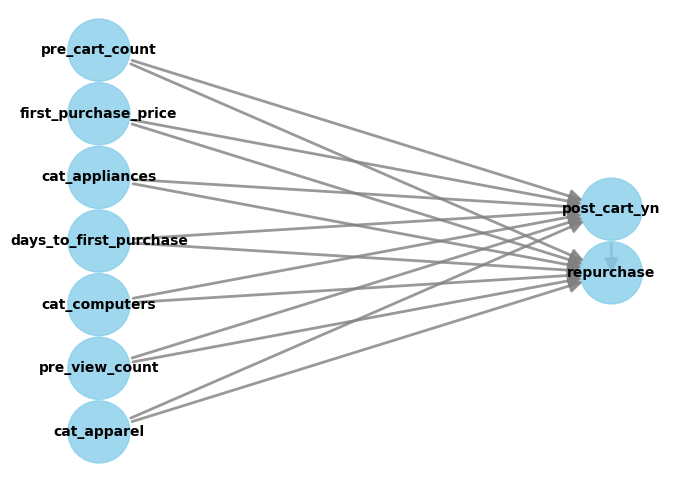

In [4]:
from dowhy import CausalModel

model = CausalModel(
    data=causal_df_model,   # 표준화된 데이터로 통일 (PSM/IPW와 기준 일치)
    treatment=T_col,      # 'post_cart_yn'
    outcome=Y_col,         # 'repurchase'
    common_causes=W_cols,  # 교란요인 7개 리스트
)

model.view_model()


## 4. Identify — 설정한 인과구조에서의 식별

DAG에서 W를 보정하면 어떤 식으로 효과를 추정할 수 있는지 확인한다. 이 계산은 설정한 인과구조가 맞다는 가정 아래 이루어지며, 실제 데이터에 미관측 교란이 없다는 것을 증명하지 않는다.


### Identify 결과

설정한 인과구조 아래에서 Backdoor 식별식을 얻었다. 이는 관측하지 못한 교란요인이 없거나 시간 설계가 타당하다는 사실을 확인한 것은 아니다.


In [ ]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[repurchase|pre_view_count,first_purchase_price,cat_computers ↪
d[post_cart_yn]                                                                ↪

↪                                                                    
↪ ,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count])
↪                                                                    
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,pre_view_count,first_purchase_price,cat_computers,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count,U) = P(repurchase|post_cart_yn,pre_view_count,first_purchase_price,cat_computers,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

##

## 5. Estimate — PSM/IPW로 ATE 추정

설정한 인과 가정 아래 관측된 W를 보정하여 ATE를 두 가지 방법으로 추정한다.

- **PSM**: T=1일 확률(성향점수)을 W로 예측하고, 점수가 비슷한 T=0/T=1을
  짝지어 그 차이만 본다.
- **IPW**: 짝짓기 대신 성향점수의 역수를 가중치로 써서 전체 표본을 그대로
  쓴다.

계산 원리가 다른 두 방법이 같은 답을 내는지가 포인트다.

### Estimate 결과

| 구분 | 재구매율 차이 |
|---|---|
| 통제 전 (raw) | 44.3%p |
| PSM | 45.3%p (95% CI [44.6, 46.0]%p) |
| IPW | 45.2%p |

구매 전 특성을 보정한 뒤에도 재추가 집단의 재구매율이 높게 추정됐다. PSM 양방향 매칭과 실제 IPW 가중치를 검사한 결과, 두 방법 모두 관측 변수의 균형 기준을 충족했다. 신뢰구간은 원본 실행 보고값이며 이번 검증 코드 수정에서 재계산하지 않았다.


In [ ]:
from sklearn.linear_model import LogisticRegression

# 표준화된 causal_df_model 기준. 기본 max_iter=100은 수렴하지 않을 수 있어 상향.
propensity_model = LogisticRegression(max_iter=1000)

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    method_params={"propensity_score_model": propensity_model}
)
# IPW 실행이 성향점수 열을 제한하기 전에 PSM에서 사용한 점수를 보관한다.
psm_scores = causal_df_model[estimate.estimator.propensity_score_column].copy()
print(estimate)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[repurchase|pre_view_count,first_purchase_price,cat_computers ↪
d[post_cart_yn]                                                                ↪

↪                                                                    
↪ ,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count])
↪                                                                    
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,pre_view_count,first_purchase_price,cat_computers,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count,U) = P(repurchase|post_cart_yn,pre_view_count,first_purchase_price,cat_computers,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count)

## Realized estim

In [ ]:
estimate_ipw = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_weighting",
    method_params={"propensity_score_model": propensity_model}
)
# ATE 추정에 실제 사용한 가중치를 보관한다(기본 성향점수 범위 0.05~0.95).
ipw_weights = causal_df_model[estimate_ipw.estimator.weighting_scheme].copy()
print(estimate_ipw)

ipw_ate = estimate_ipw.value
print(f'IPW ATE: {ipw_ate:.4f}')


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                       ↪
───────────────(E[repurchase|pre_view_count,first_purchase_price,cat_computers ↪
d[post_cart_yn]                                                                ↪

↪                                                                    
↪ ,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count])
↪                                                                    
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,pre_view_count,first_purchase_price,cat_computers,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count,U) = P(repurchase|post_cart_yn,pre_view_count,first_purchase_price,cat_computers,cat_apparel,cat_appliances,days_to_first_purchase,pre_cart_count)

## Realized estim

In [8]:
ci = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    confidence_intervals=True
)
print(ci)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                                                               ↪
───────────────(E[repurchase|cat_apparel,pre_view_count,cat_computers,days_to_first_purchase,cat_appliances,first_purc ↪
d[post_cart_yn]                                                                                                        ↪

↪                            
↪ hase_price,pre_cart_count])
↪                            
Estimand assumption 1, Unconfoundedness: If U→{post_cart_yn} and U→repurchase then P(repurchase|post_cart_yn,cat_apparel,pre_view_count,cat_computers,days_to_first_purchase,cat_appliances,first_purchase_price,pre_cart_count,U) = P(repurchase|post_cart_yn,cat_apparel,pre_view_count,cat_computers,days_to_first_purchase,cat_appliances,first_purchase_price,pre_cart_count)

## Realized estim

### 5-1. 조정 후 Covariate Balance

PSM의 양방향 매칭과 IPW 추정에 사용한 실제 가중치를 검사한다. 최대 |SMD|는 PSM 재추가 기준 0.039, 미재추가 기준 0.032, IPW 0.016으로 모두 기준 0.1 미만이었다. 기존 IPW 실패 판정은 추정과 다른 가중치를 검사한 데서 발생했다.


In [ ]:
from sklearn.neighbors import NearestNeighbors

# 별도 성향점수 재적합 없이, 실제 PSM 점수와 IPW 가중치로 검증한다.
check_df = causal_df_model[W_cols + [T_col]].copy()
check_df['propensity_score'] = psm_scores
check_df['ipw_weight'] = ipw_weights
treated = check_df[check_df[T_col] == 1]
control = check_df[check_df[T_col] == 0]

def matched(base, pool):
    nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(pool[['propensity_score']])
    idx = nn.kneighbors(base[['propensity_score']], return_distance=False).ravel()
    return pool.iloc[idx]

def smd(g1, g0):
    pooled = np.sqrt((g1[W_cols].var() + g0[W_cols].var()) / 2)
    return (g1[W_cols].mean() - g0[W_cols].mean()) / pooled.replace(0, np.nan)

# 전체 ATE에 사용한 양방향 매칭을 모두 검사한다.
balance_table = pd.DataFrame({
    'SMD_before': smd_before_df,
    'SMD_PSM_treated': smd(treated, matched(treated, control)),
    'SMD_PSM_control': smd(matched(control, treated), control),
})
pooled = np.sqrt((treated[W_cols].var() + control[W_cols].var()) / 2)
balance_table['SMD_IPW'] = (
    np.average(treated[W_cols], axis=0, weights=treated['ipw_weight']) -
    np.average(control[W_cols], axis=0, weights=control['ipw_weight'])
) / pooled.replace(0, np.nan)
print(balance_table)
print('\n최대 |SMD|:')
print(balance_table.abs().max())
# 0.1 미만은 확인한 변수의 평균 균형 기준이며, 인과 가정의 증명은 아니다.


                        SMD_before  SMD_PSM_treated  SMD_PSM_control   SMD_IPW
cat_apparel              -0.048692         0.021396         0.008629 -0.010172
cat_appliances           -0.114429         0.035375         0.010998  -0.00999
cat_computers            -0.037890         0.006241        -0.001128  -0.00061
days_to_first_purchase    0.178540         0.022419        -0.010566 -0.004722
first_purchase_price      0.107824        -0.028596         0.000978  0.004892
pre_cart_count            0.153616         0.026012         0.031708  0.016331
pre_view_count            0.054460         0.039060        -0.014020 -0.008432

최대 |SMD|:
SMD_before          0.17854
SMD_PSM_treated     0.03906
SMD_PSM_control    0.031708
SMD_IPW            0.016331
dtype: object


### 5-2. 결과 통합

Raw 44.3%p, PSM 45.3%p, IPW 45.2%p로 큰 양의 차이가 남았다. 두 방법 모두 확인한 관측 변수의 균형 기준을 충족했다.


In [ ]:
raw_gap = causal_df.groupby(T_col)[Y_col].mean().diff().iloc[-1]

summary_table = pd.DataFrame({
    '구분': ['Raw (통제 전)', 'PSM', 'IPW'],
    '재구매율 차이': [raw_gap, estimate.value, estimate_ipw.value],
})
print(summary_table)

print('\n조정 전/후 SMD 요약 (|SMD| > 0.1 = 불균형):')
print(balance_table)


           구분   재구매율 차이
0  Raw (통제 전)  0.442647
1         PSM  0.453459
2         IPW  0.452327

조정 전/후 SMD 요약 (|SMD| > 0.1 = 불균형):
                        SMD_before  SMD_PSM_treated  SMD_PSM_control   SMD_IPW
cat_apparel              -0.048692         0.021396         0.008629 -0.010172
cat_appliances           -0.114429         0.035375         0.010998  -0.00999
cat_computers            -0.037890         0.006241        -0.001128  -0.00061
days_to_first_purchase    0.178540         0.022419        -0.010566 -0.004722
first_purchase_price      0.107824        -0.028596         0.000978  0.004892
pre_cart_count            0.153616         0.026012         0.031708  0.016331
pre_view_count            0.054460         0.039060        -0.014020 -0.008432


### 6-1. Placebo Treatment Test

장바구니 재추가 대신 무작위로 생성한 가짜 처치를 넣어 추정치가 0에 가까운지 확인한다. 가짜 처치에서도 큰 차이가 나온다면 추정 과정과 데이터를 점검해야 한다. 이 검증만으로 실제 처치의 인과성이 확인되지는 않는다.


**재실행 결과**

원래 PSM 추정치: 45.346%p

검증 추정치: 0.015%p

p-value: 0.9200

무작위 가짜 처치 100회 결과다. 인과관계를 증명하는 검사는 아니다.


In [ ]:
# 검증별 난수 고정. 원본 시간 조건과 PSM 추정치는 유지한다.
np.random.seed(42)
# 저장된 성향점수를 제거해 가짜 처치·부분 표본·가상 교란에 맞춰 다시 적합한다.
causal_df_model.drop(columns=estimate.estimator.propensity_score_column, errors="ignore", inplace=True)
refute_placebo = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="placebo_treatment_refuter",
    num_simulations=100
)
print(refute_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.45345878810688744
New effect:0.00015120812946932633
p value:0.9199999999999999



### 6-2. Data Subset Refuter

전체 고객의 80%를 무작위로 뽑아 같은 추정을 100회 반복한다. 전체 표본 추정치 약 45.35%p와 비교해 표본 변경에 대한 안정성을 확인한다.


In [ ]:
# 검증별 난수 고정. 원본 시간 조건과 PSM 추정치는 유지한다.
np.random.seed(42)
refute_subset = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=100
)
print(refute_subset)

Refute: Use a subset of data
Estimated effect:0.45345878810688744
New effect:0.4550707188558525
p value:0.6799999999999999



**재실행 결과**

원래 PSM 추정치: 45.346%p

검증 추정치: 45.507%p

p-value: 0.6800

80% 부분 표본 100회 추정치의 평균이다. 표본 변경에 대한 안정성을 확인한다.


### 6-3. Unobserved Confounder Sensitivity Test

가상의 교란을 추가해 추정치가 어떻게 달라지는지 확인한다. 원본 설정인 처치 binary_flip=0.05와 결과 linear=0.05를 유지한다. 전자는 약 5%의 처치 상태 뒤집기, 후자는 가상 교란값에 대한 선형계수다. 둘을 동일한 현실의 “5% 교란 세기”로 해석하지 않는다. 결과값이 0/1 밖으로도 변할 수 있는 인위적 시나리오이며, 미관측 교란이 제거됐다는 검증은 아니다.


In [ ]:
# 검증별 난수 고정. 원본 시간 조건과 PSM 추정치는 유지한다.
np.random.seed(42)
refute_unobserved = model.refute_estimate(
    identified_estimand,
    estimate,
    method_name="add_unobserved_common_cause",
    confounders_effect_on_treatment="binary_flip",
    confounders_effect_on_outcome="linear",
    effect_strength_on_treatment=0.05,
    effect_strength_on_outcome=0.05
)
print(refute_unobserved)

Refute: Add an Unobserved Common Cause
Estimated effect:0.45345878810688744
New effect:0.26282227255506063



**재실행 결과**

원래 PSM 추정치: 45.346%p

검증 추정치: 26.282%p

원본의 binary_flip=0.05, linear=0.05 시나리오다. 방향과 크기의 변화를 살피며, 현실의 모든 미관측 교란을 검증한 것은 아니다.


## 7. 결론

구매 전 특성이 비슷한 고객끼리 비교해도, 장바구니에 다시 담은 고객의 재구매율이 높았다. PSM에서는 약 45.3%p, IPW에서는 약 45.2%p의 차이가 추정됐다. 두 방법 모두 관측 변수의 균형 기준을 충족했다.

장바구니 재추가를 유도하는 알림·리마인더를 CRM 실험 후보로 제안한다. 실제 재구매 증가 효과는 A/B 테스트로 확인한다.

### 한계

- 구매 의향처럼 측정하지 못한 요인과 고객별 행동 관측 기간의 차이가 결과에 영향을 줄 수 있다. 재구매하면 행동 관찰을 끝내며, 첫 24시간의 행동은 제외하므로 조기 재구매자는 재추가 없음으로 분류된다.
- 최소 관측 기간은 18일이지만 재구매 라벨은 19일 미만까지 포함하여, 일부 고객은 정답 구간 전체를 관측하지 못했다.
- 재구매는 두 번째 purchase 이벤트 기준이다. 별도 주문·방문 여부를 확인한 정의가 아니다.
- 자연발생적 재추가에 대한 추정치와 CRM으로 재추가를 유도했을 때의 효과는 다르다. 균형·추가 검증만으로 인과효과를 확정하지 않는다.
